In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('netlfix.csv')

In [3]:
df.head

<bound method NDFrame.head of      date_added        week             category  \
0    28-06-2022  26-06-2022      Films (English)   
1    26-04-2022  24-04-2022     TV (Non-English)   
2    14-06-2022  12-06-2022      Films (English)   
3    28-06-2022  26-06-2022      Films (English)   
4    12-04-2022  10-04-2022  Films (Non-English)   
..          ...         ...                  ...   
515  31-05-2022  29-05-2022         TV (English)   
516  12-04-2022  10-04-2022      Films (English)   
517  28-06-2022  26-06-2022      Films (English)   
518  07-06-2022  05-06-2022      Films (English)   
519  12-04-2022  10-04-2022         TV (English)   

                          consolidated_title  weekly_rank  \
0                                     Hustle            3   
1                Heirs to the Land: Season 1            5   
2                          A Perfect Pairing            6   
3                       The Man from Toronto            1   
4                                    Fur

In [4]:
df.columns

Index(['date_added', 'week', 'category', 'consolidated_title', 'weekly_rank',
       'cumulative_weeks_in_top_10', 'weekly_hours_viewed', 'imdb_rating',
       'runtime'],
      dtype='object')

In [5]:
df.isna().sum()

date_added                      0
week                            0
category                        0
consolidated_title              0
weekly_rank                     0
cumulative_weeks_in_top_10      0
weekly_hours_viewed            40
imdb_rating                   142
runtime                       166
dtype: int64

In [6]:
# selecting numeric columns

features = ['weekly_rank',
    'cumulative_weeks_in_top_10',
    'weekly_hours_viewed',
    'imdb_rating',
    'runtime'
]

df_numeric = df[features]

In [7]:
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')

# Mark suspicious runtimes as NaN
df.loc[(df['category'].str.contains('TV')) & (df['runtime'] < 20), 'runtime'] = np.nan
df.loc[(df['category'].str.contains('Films')) & (df['runtime'] < 60), 'runtime'] = np.nan

df['runtime'] = df.groupby('category')['runtime'].transform(
    lambda x: x.fillna(x.median())
)

df['runtime'] = df['runtime'].round(0).astype(int)

In [8]:
def regression_impute(df, target_column, feature_columns):

    # Ensure numeric
    df[feature_columns] = df[feature_columns].apply(pd.to_numeric, errors='coerce')
    df[target_column] = pd.to_numeric(df[target_column], errors='coerce')

    train = df[df[target_column].notna()]
    test = df[df[target_column].isna()]

    if test.empty:
        print(f"No missing values in {target_column}")
        return df

    if train.empty:
        print(f"No training data for {target_column}")
        return df

    X_train = train[feature_columns].copy()
    X_test = test[feature_columns].copy()
    y_train = train[target_column]

    # Replace infinite values
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    # Fill with median
    global_median = df[feature_columns].median()
    X_train = X_train.fillna(global_median)
    X_test = X_test.fillna(global_median)

    # 🔎 Final check
    if X_train.isna().sum().sum() > 0:
        print("Still NaNs present in training features")
        return df

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    df.loc[df[target_column].isna(), target_column] = predictions

    print(f"Filled {len(predictions)} values in {target_column}")

    return df

In [9]:
def predict_weekly_hours_rf(df):

    features = [
        'weekly_rank',
        'cumulative_weeks_in_top_10',
        'runtime',
        'imdb_rating'
    ]
     
    # Convert to numeric properly
    df[features + ['weekly_hours_viewed']] = \
        df[features + ['weekly_hours_viewed']].apply(pd.to_numeric, errors='coerce')

    # Fill feature NaNs first
    df[features] = df[features].fillna(df[features].median())

    train = df[df['weekly_hours_viewed'].notna()]
    test = df[df['weekly_hours_viewed'].isna()]

    if test.empty:
        print("No missing weekly_hours_viewed values")
        return df

    X_train = train[features]
    y_train = train['weekly_hours_viewed']
    X_test = test[features]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    df.loc[df['weekly_hours_viewed'].isna(), 'weekly_hours_viewed'] = predictions

    df['weekly_hours_viewed'] = df['weekly_hours_viewed'].round(0)

    print(f"Filled {len(predictions)} weekly_hours_viewed values")

    return df

In [10]:
df = predict_weekly_hours_rf(df)

Filled 40 weekly_hours_viewed values


In [11]:
# predict imdb rating
df = regression_impute(
    df,
    'imdb_rating',
    ['weekly_rank', 'cumulative_weeks_in_top_10', 'runtime', 'weekly_hours_viewed']
)

df['imdb_rating'] = df['imdb_rating'].round(1).clip(0,10)

print("Remaining missing values:")
print(df[['weekly_hours_viewed','imdb_rating','runtime']].isna().sum())

No missing values in imdb_rating
Remaining missing values:
weekly_hours_viewed    0
imdb_rating            0
runtime                0
dtype: int64


In [12]:
df.to_csv('netflix_imputed_dataset.csv', index=False)

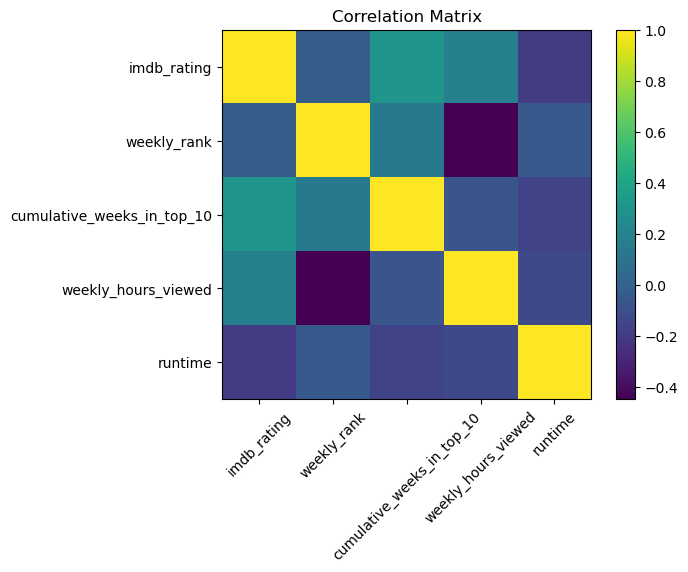

In [16]:
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_imputed_dataset.csv')

numeric_cols = [
    'imdb_rating',
    'weekly_rank',
    'cumulative_weeks_in_top_10',
    'weekly_hours_viewed',
    'runtime'
]

corr = df[numeric_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

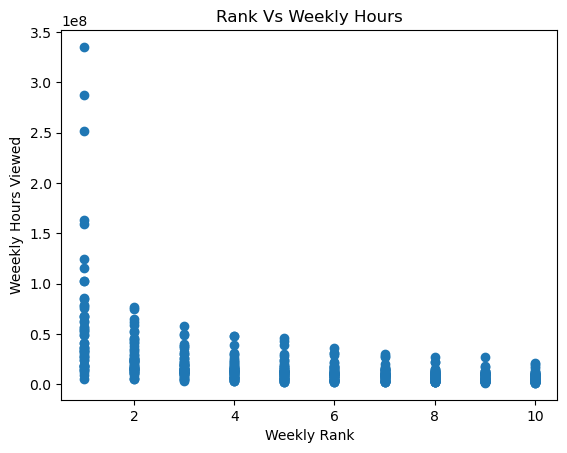

In [17]:
plt.figure
plt.scatter(df['weekly_rank'], df['weekly_hours_viewed'])
plt.xlabel("Weekly Rank")
plt.ylabel("Weeekly Hours Viewed")
plt.title("Rank Vs Weekly Hours")
plt.show

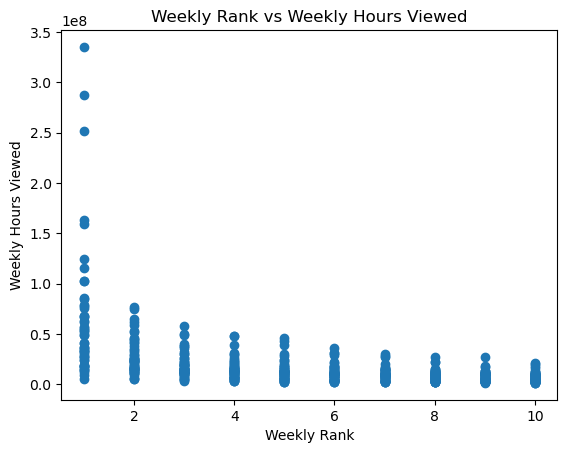

In [18]:
plt.figure()
plt.scatter(df['weekly_rank'], df['weekly_hours_viewed'])
plt.xlabel("Weekly Rank")
plt.ylabel("Weekly Hours Viewed")
plt.title("Weekly Rank vs Weekly Hours Viewed")
plt.show()

<Figure size 640x480 with 0 Axes>

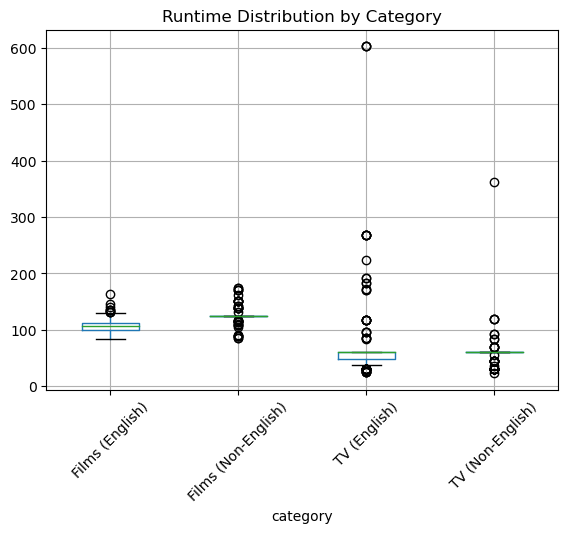

In [19]:
plt.figure()
df.boxplot(column='runtime', by='category')
plt.xticks(rotation=45)
plt.title("Runtime Distribution by Category")
plt.suptitle("")
plt.show()

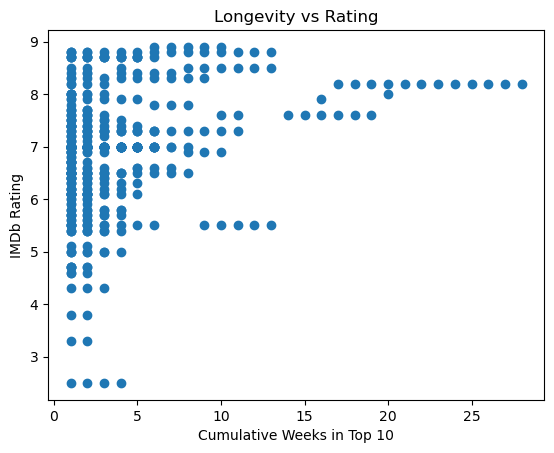

In [20]:
plt.figure()
plt.scatter(df['cumulative_weeks_in_top_10'], df['imdb_rating'])
plt.xlabel("Cumulative Weeks in Top 10")
plt.ylabel("IMDb Rating")
plt.title("Longevity vs Rating")
plt.show()

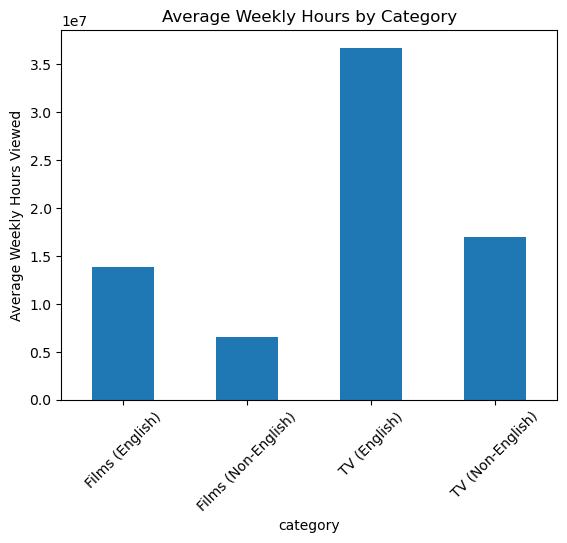

In [21]:
avg_hours = df.groupby('category')['weekly_hours_viewed'].mean()

plt.figure()
avg_hours.plot(kind='bar')
plt.ylabel("Average Weekly Hours Viewed")
plt.title("Average Weekly Hours by Category")
plt.xticks(rotation=45)
plt.show()